# 06a: Using Matplotlib to Create Animation

This notebooks shows how to create an animation that will run and play inside a notebook.  The animation can also be written to a video file.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.animation as animation
from IPython.display import HTML

import cartopy
import cartopy.crs as ccrs

ModuleNotFoundError: No module named 'cartopy'

In [2]:
def get_y(x, a, b, c, d):
    y = a * np.sin(b * x + c) + d
    return y

fig, ax = plt.subplots()
x = np.linspace(0, 2 * np.pi, 100)

a = 1
b = 1
c = 0
d = 0
y0 = get_y(x, a, b, c, d)

line = ax.plot(x, y0, 'b-', clip_on=False)
line = line[0]

xd = np.pi
yd = get_y(xd, a, b, c, d)
dot = ax.plot(xd, yd, 'ro', ms=10, clip_on=False)
dot = dot[0]

ax.set_xlim(0, 2 * np.pi)
ax.set_ylim(-a, a)

frames = 50

def update(i):

    dt = 2 * np.pi / frames
    c = i * dt

    # for each frame, update the data stored on each artist.
    y = get_y(x, a, b, c, d)
    line.set_xdata(x)
    line.set_ydata(y)

    yd = get_y(xd, a, b, c, d)
    dot.set_ydata([yd])

    return line,

ani = animation.FuncAnimation(fig=fig, func=update, frames=frames)
plt.close()


HTML(ani.to_jshtml())

In [3]:
# the following can be used to save the animation to a file
ext = "mp4" # mac mp4
# ext = "avi" # windows avi
ani.save(f"sin_animation.{ext}")

## a map example

## Plotting data on maps

Creating some data that spans the whole globe.

In [4]:
lon, lat = np.mgrid[-180:181, -90:91]

# build a fake dataset that shifts through n time steps
n = 45
data = np.array([2 * np.sin(3 * np.deg2rad(lon+dt)) + 3 * np.cos(4 * np.deg2rad(lat+dt))
                 for dt in np.arange(0,n)])

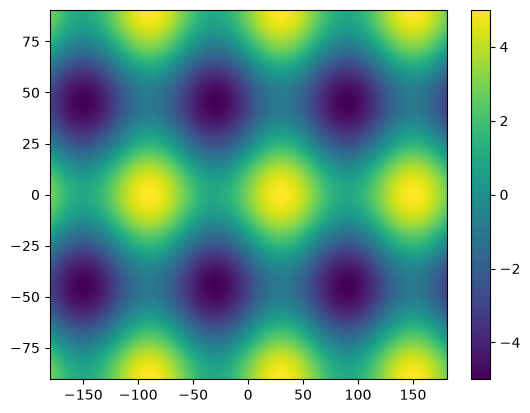

In [5]:
# let's check the first time step
plt.pcolormesh(lon, lat, data[0])
plt.colorbar();

Now let's animate it!

In [6]:
fig, ax = plt.subplots()
mesh = ax.pcolormesh(lon, lat, data[0])
fig.colorbar(mesh, orientation='vertical')

def animate(i):
    h = data[i]
    mesh.set_array(h)
    title = ax.set_title(f'Year {i+1}')
    return mesh

ani = animation.FuncAnimation(
    fig, 
    animate, 
    frames=data.shape[0],
    # save_count=data.shape[0],
    # interval=500,
)
plt.close()

HTML(ani.to_jshtml())

### Geospatially

Plotting data on a Cartesian grid is equivalent to plotting data in the PlateCarree projection, where meridians and parallels are all straight lines with constant spacing. As a result of this simplicity, global datasets we use often begin in the PlateCarree projection.

We can plot these data values as a contour on a `GeoAxes` map. To do so, we must specify the `transform` keyword argument, which specifies the projection type used by our data. The `transform` keyword can be given to all matplotlib plotting methods. The projection type specified in `pcolormesh` will be transformed into the projection type specified in the `subplot` method.

In [7]:
fig = plt.figure(figsize=(11, 8.5))
ax = plt.subplot(1, 1, 1, projection=ccrs.Orthographic(central_latitude=45))
ax.coastlines()
mesh = ax.pcolormesh(lon, lat, data[0], transform=ccrs.PlateCarree())
plt.colorbar(mesh, orientation='horizontal', pad=.05);

NameError: name 'ccrs' is not defined

<Figure size 1100x850 with 0 Axes>

## Class Activity

Animate the above `GeoAxes` in the way we had done with the simpler graph previously. 

Bonus: How does it work if you switch over to using `contourf` instead?